**Movie Genre Classification**

Uploading Dataset ZIP File

In [20]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

Extracting Dataset

In [5]:
from zipfile import ZipFile

zip_name = list(uploaded.keys())[0]

with ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


Verifying Dataset Files

In [6]:
import os

for root, dirs, files in os.walk('dataset'):
    for file in files:
        print(os.path.join(root, file))

dataset/Genre Classification Dataset/test_data_solution.txt
dataset/Genre Classification Dataset/train_data.txt
dataset/Genre Classification Dataset/test_data.txt
dataset/Genre Classification Dataset/description.txt


Importing Required Libraries

In [7]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

Loading Training Dataset

In [8]:
train_df = pd.read_csv(
    "dataset/Genre Classification Dataset/train_data.txt",
    sep=" ::: ",
    engine="python",
    names=["ID","TITLE","GENRE","DESCRIPTION"]
)

train_df.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


Loading Test Dataset

In [9]:
test_df = pd.read_csv(
    "dataset/Genre Classification Dataset/test_data.txt",
    sep=" ::: ",
    engine="python",
    names=["ID","TITLE","DESCRIPTION"]
)

solution_df = pd.read_csv(
    "dataset/Genre Classification Dataset/test_data_solution.txt",
    sep=" ::: ",
    engine="python",
    names=["ID","TITLE","GENRE","DESCRIPTION"]
)

Dataset Overview

In [10]:
print("Training Shape:", train_df.shape)

print("\nMissing Values:")
print(train_df.isnull().sum())

print("\nTop Genres:")
print(train_df["GENRE"].value_counts().head())

Training Shape: (54214, 4)

Missing Values:
ID             0
TITLE          0
GENRE          0
DESCRIPTION    0
dtype: int64

Top Genres:
GENRE
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
Name: count, dtype: int64


Feature Selection

In [11]:
X_train = train_df["DESCRIPTION"]
y_train = train_df["GENRE"]

X_test = test_df["DESCRIPTION"]
y_test = solution_df["GENRE"]

TF-IDF Vectorization

In [12]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Matrix:", X_train_tfidf.shape)

Training Matrix: (54214, 10000)


Logistic Regression Model Training

In [13]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model Training Completed")

Model Training Completed


Predict Movie Genres

In [14]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

['drama' 'drama' 'documentary' 'drama' 'drama' 'drama' 'drama' 'comedy'
 'documentary' 'drama']


Accuracy Score

In [15]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 58.88%


Classification Report

In [16]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

      action       0.51      0.29      0.37      1314
       adult       0.62      0.25      0.35       590
   adventure       0.64      0.16      0.25       775
   animation       0.53      0.05      0.10       498
   biography       0.00      0.00      0.00       264
      comedy       0.54      0.59      0.57      7446
       crime       0.37      0.03      0.06       505
 documentary       0.67      0.86      0.75     13096
       drama       0.54      0.78      0.64     13612
      family       0.52      0.09      0.16       783
     fantasy       0.50      0.04      0.07       322
   game-show       0.91      0.49      0.64       193
     history       0.00      0.00      0.00       243
      horror       0.66      0.58      0.62      2204
       music       0.69      0.44      0.54       731
     musical       0.42      0.02      0.03       276
     mystery       0.22      0.01      0.01       318
        news       0.71    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix

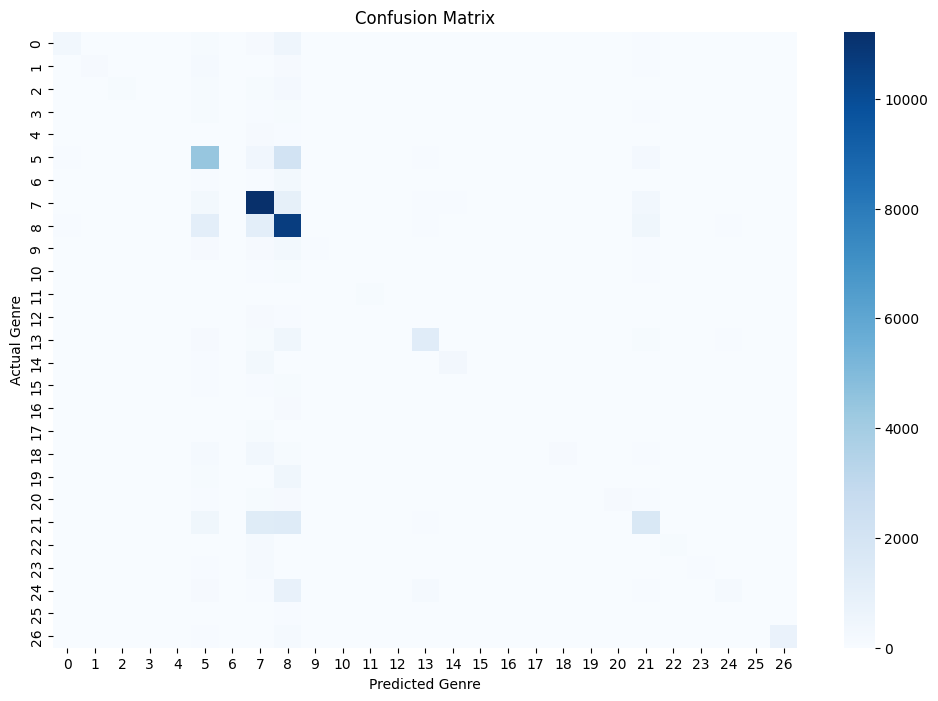

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")

plt.show()

Test Custom Movie Description

In [18]:
sample_plot = [
    "A superhero saves the world from dangerous villains."
]

sample_vector = tfidf.transform(sample_plot)

prediction = model.predict(sample_vector)

print("Predicted Genre:", prediction[0])

Predicted Genre: action
